# Animate OP01 Thermal Layers Over Time

This notebook animates the three thermal grid layers of an OP bundle as time
advances:

- **Cell Center** (`cc`)
- **Gehaeusewand** (`g`, housing wall)
- **JR1 Center** (`jr1c`)

The temperature field `T` from `data_cache/OP01.npz` has shape
`(n_time, n_sensors)`. Each layer holds 121 sensors (an 11x11 grid). We draw one
filled-contour panel per layer with a shared colour scale and step through time.
The animation is shown inline and saved as a GIF in this folder.


In [1]:
# 1. Import Required Libraries
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Image, display

# The reusable animation helpers live next to this notebook.
import sys
HERE = Path.cwd()
if (HERE / "animate_layers.py").exists():
    NB_DIR = HERE
else:
    NB_DIR = HERE / "battery_surrogate_agenticWorkflow" / "animations" / "op_layer_animation"
sys.path.insert(0, str(NB_DIR))

from animate_layers import LAYER_LABELS, LAYER_ORDER, load_op_arrays, build_layer_animation

# Locate the workflow root and the OP cache directory.
WORKFLOW_ROOT = NB_DIR.parents[1]  # .../battery_surrogate_agenticWorkflow
CACHE_DIR = WORKFLOW_ROOT / "data_cache"
print("Notebook dir :", NB_DIR)
print("Cache dir    :", CACHE_DIR, "(exists:", CACHE_DIR.exists(), ")")


Notebook dir : c:\Users\M0245635\batterysurrogatemodell\battery_surrogate_agenticWorkflow\animations\op_layer_animation
Cache dir    : c:\Users\M0245635\batterysurrogatemodell\battery_surrogate_agenticWorkflow\data_cache (exists: True )


## 2. Define Layer Data Structures

Load the OP bundle and split the temperature field into the three layers. Each
layer keeps its sensor column indices and the 2D coordinates (the plane the
layer lives in) so we can draw a filled contour per frame.


In [2]:
# 2. Define Layer Data Structures
OP_ID = "OP01"
npz_path = CACHE_DIR / f"{OP_ID}.npz"

arrays = load_op_arrays(npz_path)
T = arrays["T"]            # (n_time, n_sensors) temperatures in degC
t_fast = arrays["t_fast"]  # (n_time,) time axis in seconds
xyz = arrays["xyz"]        # (n_sensors, 3) coordinates in metres
layer = np.asarray([str(v) for v in arrays["layer"]])  # (n_sensors,)

n_time, n_sensors = T.shape
print(f"{OP_ID}: T shape = {T.shape}, time span = {t_fast[0]:.1f}..{t_fast[-1]:.1f} s")
print("Layers found:", {name: int((layer == name).sum()) for name in LAYER_ORDER})


def _varying_axes(coords: np.ndarray) -> tuple[int, int]:
    """Return the two coordinate axes with the largest spread (the layer plane)."""
    spread = coords.std(axis=0)
    return tuple(int(i) for i in np.argsort(spread)[-2:][::-1])


# Build a small record per layer: column indices + the 2D plane coordinates.
panels = []
for name in LAYER_ORDER:
    cols = np.where(layer == name)[0]
    if cols.size == 0:
        continue
    coords = xyz[cols]
    ax_a, ax_b = _varying_axes(coords)
    panels.append({
        "name": name,
        "label": LAYER_LABELS.get(name, name),
        "cols": cols,
        "u": coords[:, ax_a],
        "v": coords[:, ax_b],
    })

print("Panels:", [p["label"] for p in panels])


OP01: T shape = (14450, 363), time span = 0.1..1445.0 s
Layers found: {'cc': 121, 'g': 121, 'jr1c': 121}
Panels: ['Cell Center', 'Gehaeusewand', 'JR1 Center']


## 3. Generate Layer Content Over Time

Pick a set of evenly spaced time frames across the simulation and compute a
shared colour scale so the three layers are directly comparable.


In [3]:
# 3. Generate Layer Content Over Time
N_FRAMES = 60
LEVELS = 30
CMAP = "inferno"

frame_idx = np.linspace(0, n_time - 1, num=min(N_FRAMES, n_time)).astype(int)

sampled = T[frame_idx]
vmin = float(np.nanmin(sampled))
vmax = float(np.nanmax(sampled))
contour_levels = np.linspace(vmin, vmax, LEVELS)

print(f"Frames: {len(frame_idx)}  |  temperature range: {vmin:.2f} .. {vmax:.2f} degC")


Frames: 60  |  temperature range: 25.00 .. 46.62 degC


## 4. Set Up the Animation Figure

Create one subplot per layer, arranged side by side, with a single shared
colour bar for temperature.


Figure ready with panels: ['Cell Center', 'Gehaeusewand', 'JR1 Center']


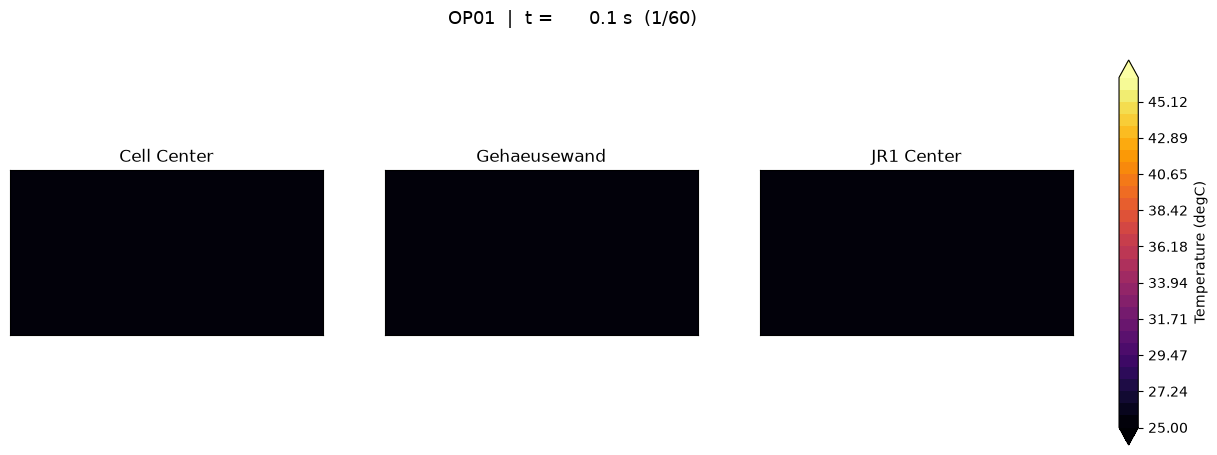

In [4]:
# 4. Set Up the Animation Figure
plt.ioff()  # build the animation off-screen; we display it explicitly below.

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
if len(panels) == 1:
    axes = [axes]


def draw_frame(frame_number: int):
    """Draw all three layers for one time frame; returns the last mappable."""
    t_index = frame_idx[frame_number]
    mappable = None
    for ax, panel in zip(axes, panels):
        ax.clear()
        values = T[t_index, panel["cols"]]
        mappable = ax.tricontourf(
            panel["u"], panel["v"], values,
            levels=contour_levels, cmap=CMAP, extend="both",
        )
        ax.set_title(panel["label"])
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(
        f"{OP_ID}  |  t = {t_fast[t_index]:8.1f} s  ({frame_number + 1}/{len(frame_idx)})",
        fontsize=13,
    )
    return mappable


# Initialise the figure with the first frame and add the shared colour bar.
first = draw_frame(0)
cbar = fig.colorbar(first, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label("Temperature (degC)")
print("Figure ready with panels:", [p["label"] for p in panels])


## 5. Create the Animation Update Function

`FuncAnimation` calls this each frame; it simply delegates to `draw_frame`,
which redraws all three layer panels for the current time step.


In [5]:
# 5. Create the Animation Update Function
def update(frame_number: int):
    draw_frame(frame_number)
    return axes


anim = FuncAnimation(fig, update, frames=len(frame_idx), blit=False)
print("Animation object created:", anim)


Animation object created: <matplotlib.animation.FuncAnimation object at 0x0000017744EA74D0>


## 6. Save the Animation and Display It Inline

Save the animation to a GIF in this folder, then embed that GIF directly in the
notebook output so you can watch the three layers evolve in time.


Saved animation to: c:\Users\M0245635\batterysurrogatemodell\battery_surrogate_agenticWorkflow\animations\op_layer_animation\OP01_layers.gif


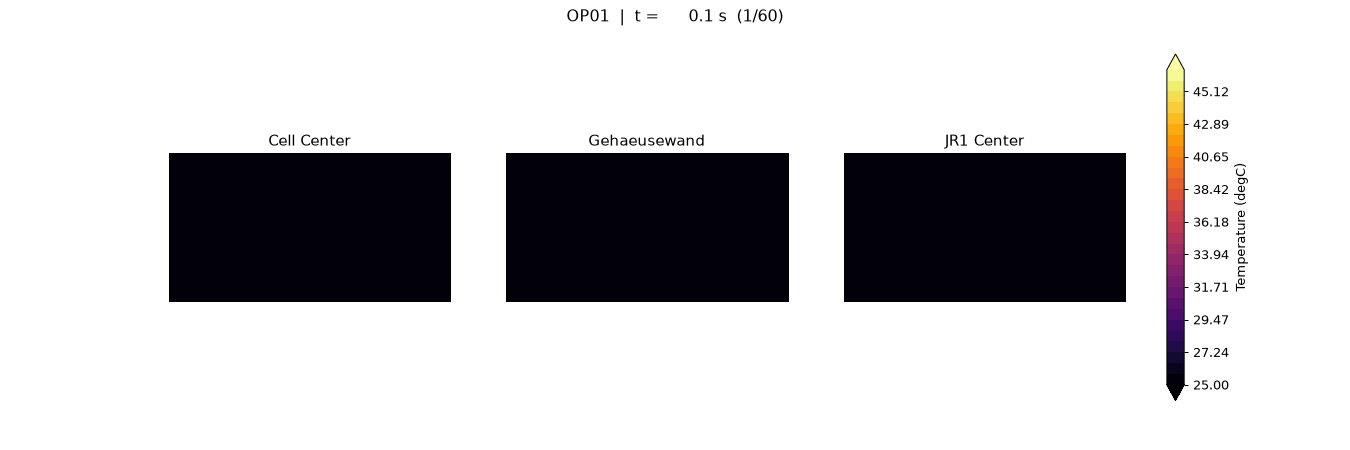

In [6]:
# 6. Save the Animation to the Folder and Display It Inline
gif_path = NB_DIR / f"{OP_ID}_layers.gif"
anim.save(gif_path, writer=PillowWriter(fps=12), dpi=90)
plt.close(fig)
print("Saved animation to:", gif_path)

# Show the GIF inline in the notebook.
display(Image(filename=str(gif_path)))


## 7. Static Snapshots (start / middle / end)

A quick non-animated check: the three layers at the first, middle, and last
sampled time step, for readers who prefer a still image.


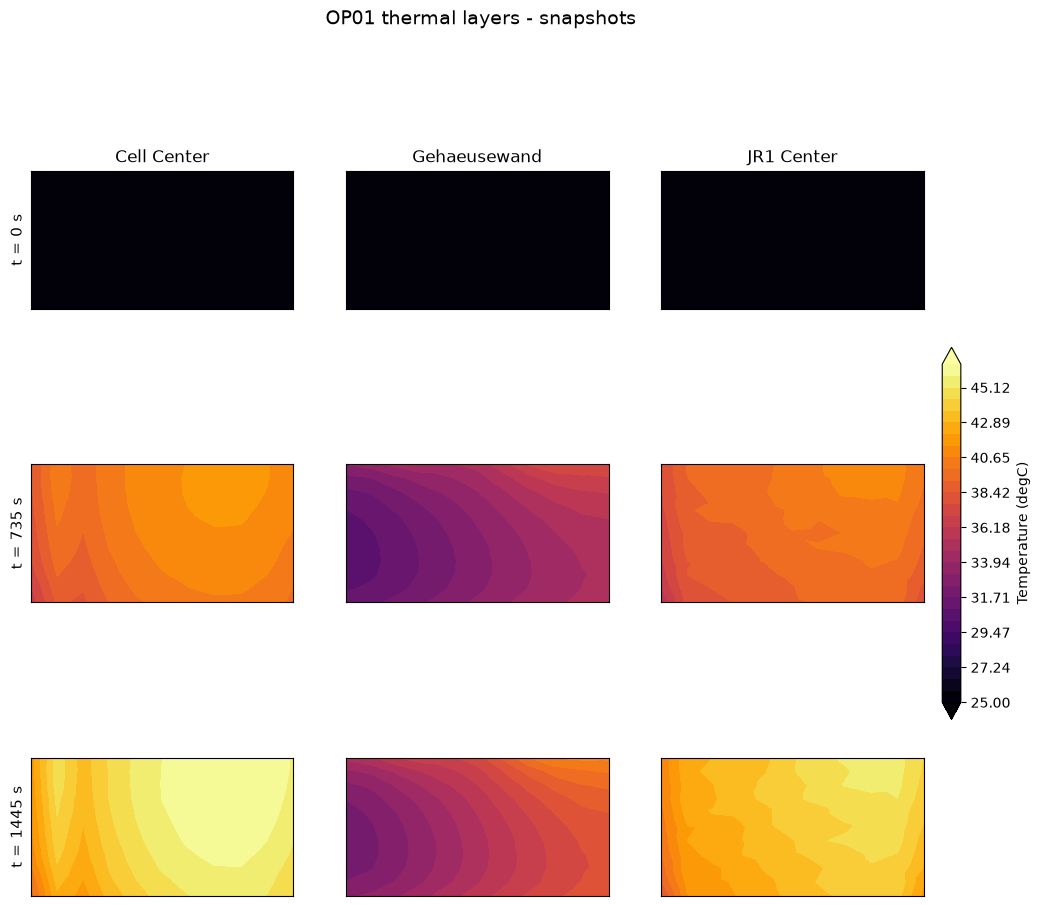

In [7]:
# 7. Static snapshots at start / middle / end
snap_frames = [0, len(frame_idx) // 2, len(frame_idx) - 1]

fig2, grid = plt.subplots(
    len(snap_frames), len(panels),
    figsize=(4 * len(panels), 3.6 * len(snap_frames)),
    squeeze=False,
)
for row, fnum in enumerate(snap_frames):
    t_index = frame_idx[fnum]
    for col, panel in enumerate(panels):
        ax = grid[row][col]
        values = T[t_index, panel["cols"]]
        cf = ax.tricontourf(
            panel["u"], panel["v"], values,
            levels=contour_levels, cmap=CMAP, extend="both",
        )
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(panel["label"])
        if col == 0:
            ax.set_ylabel(f"t = {t_fast[t_index]:.0f} s", fontsize=11)

fig2.colorbar(cf, ax=grid.ravel().tolist(), fraction=0.02, pad=0.02, label="Temperature (degC)")
fig2.suptitle(f"{OP_ID} thermal layers - snapshots", fontsize=14)
plt.show()
